In [1]:
!pip install -q "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchmetrics.image.fid import FrechetInceptionDistance
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm

def set_seed(seed=42):
    """Locks all random operations for 100% reproducible results."""
    print(f"Locking random seed to {seed} for reproducibility...")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False

set_seed(42)

Locking random seed to 42 for reproducibility...


In [3]:
class LensingNumpyDataset(Dataset):
    def __init__(self, data_dir, image_size=64, scaling="arcsinh"):
        self.data_dir = data_dir
        self.file_names = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        self.resize = transforms.Resize((image_size, image_size), antialias=True)
        self.scaling = scaling.lower() if scaling else "none"

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_names[idx])
        data = np.load(file_path)
        tensor = torch.from_numpy(data).float()
        
        if tensor.dim() == 2:
            tensor = tensor.unsqueeze(0)
        elif tensor.dim() == 3 and tensor.shape[-1] in [1, 3]:
            tensor = tensor.permute(2, 0, 1)
            
        tensor = self.resize(tensor)
        
        if self.scaling == "arcsinh":
            tensor = torch.arcsinh(tensor / 0.1)
            t_min, t_max = tensor.min(), tensor.max()
            if t_max > t_min: tensor = (tensor - t_min) / (t_max - t_min)
            tensor = tensor * 2.0 - 1.0 
        elif self.scaling == "minmax":
            t_min, t_max = tensor.min(), tensor.max()
            if t_max > t_min: tensor = (tensor - t_min) / (t_max - t_min)
            tensor = tensor * 2.0 - 1.0
        elif self.scaling == "none":
            pass
        else:
            raise ValueError("Scaling parameter must be 'arcsinh', 'minmax', or 'none'.")
        return tensor

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

def get_conv(in_ch, out_ch, kernel_size=3, padding=1, use_equivariant=False):
    if use_equivariant:
        return SymConv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding)
    return nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding)

class SymConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding)

    def forward(self, x):
        B = x.shape[0]
        x_rot = torch.cat([x, torch.rot90(x, 1, [2, 3]), torch.rot90(x, 2, [2, 3]), torch.rot90(x, 3, [2, 3])], dim=0)
        y_rot = self.conv(x_rot)
        y0, y90, y180, y270 = torch.split(y_rot, B, dim=0)
        out = y0 + torch.rot90(y90, -1, [2, 3]) + torch.rot90(y180, -2, [2, 3]) + torch.rot90(y270, -3, [2, 3])
        return out / 4.0

class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]), nn.Linear(channels, channels), nn.GELU(), nn.Linear(channels, channels)
        )

    def forward(self, x):
        b, c, h, w = x.shape
        x = x.view(b, c, h * w).swapaxes(1, 2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        x = attention_value + x
        x = self.ff_self(x) + x
        return x.swapaxes(2, 1).view(b, c, h, w)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, use_equivariant=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = get_conv(in_ch, out_ch, 3, 1, use_equivariant)
        self.conv2 = get_conv(out_ch, out_ch, 3, 1, use_equivariant)
        self.downsample = nn.Conv2d(out_ch, out_ch, 4, 2, 1) 
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()
        
    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.downsample(h), h

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim, use_equivariant=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch, 4, 2, 1) 
        self.conv1 = get_conv(in_ch + skip_ch, out_ch, 3, 1, use_equivariant)
        self.conv2 = get_conv(out_ch, out_ch, 3, 1, use_equivariant)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()
        
    def forward(self, x, skip, t):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1) 
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        return self.bnorm2(self.relu(self.conv2(h)))

class UNet(nn.Module):
    def __init__(self, img_ch=1, time_emb_dim=256, use_equivariant=False):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim), nn.Linear(time_emb_dim, time_emb_dim), nn.ReLU()
        )
        self.down1 = DownBlock(img_ch, 64, time_emb_dim, use_equivariant)
        self.down2 = DownBlock(64, 128, time_emb_dim, use_equivariant)
        self.sa1 = SelfAttention(128)
        self.down3 = DownBlock(128, 256, time_emb_dim, use_equivariant)
        self.sa2 = SelfAttention(256)
        self.down4 = DownBlock(256, 512, time_emb_dim, use_equivariant)

        self.bot1 = get_conv(512, 512, 3, 1, use_equivariant)
        self.bot2 = get_conv(512, 512, 3, 1, use_equivariant)

        self.up1 = UpBlock(512, 512, 256, time_emb_dim, use_equivariant)
        self.sa3 = SelfAttention(256)
        self.up2 = UpBlock(256, 256, 128, time_emb_dim, use_equivariant)
        self.sa4 = SelfAttention(128)
        self.up3 = UpBlock(128, 128, 64, time_emb_dim, use_equivariant)
        self.up4 = UpBlock(64, 64, 64, time_emb_dim, use_equivariant)
        self.outc = nn.Conv2d(64, img_ch, 1) 

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x, skip1 = self.down1(x, t)
        x, skip2 = self.down2(x, t)
        x = self.sa1(x)
        x, skip3 = self.down3(x, t)
        x = self.sa2(x)
        x, skip4 = self.down4(x, t)

        x = self.bot1(x)
        x = self.bot2(x)

        x = self.up1(x, skip4, t)
        x = self.sa3(x)
        x = self.up2(x, skip3, t)
        x = self.sa4(x)
        x = self.up3(x, skip2, t)
        x = self.up4(x, skip1, t)
        return self.outc(x)

In [5]:
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, img_size=64, device="cuda"):
        self.T = T
        self.img_size = img_size
        self.device = device
        self.beta = torch.linspace(beta_start, beta_end, T).to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.T, size=(n,))

    def q_sample(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise, noise

    @torch.no_grad()
    def ddim_sample_loop(self, model, n, ddim_timesteps=50, eta=0.0, return_trajectory=False, starting_noise=None):
        model.eval()
        if starting_noise is not None:
            x = starting_noise.to(self.device)
            n = x.shape[0] 
        else:
            x = torch.randn((n, 1, self.img_size, self.img_size)).to(self.device)
        
        step_size = self.T // ddim_timesteps
        times = list(reversed(range(0, self.T, step_size)))
        trajectory = []
        save_interval = max(1, ddim_timesteps // 10) 

        for i in tqdm(range(len(times)), desc="DDIM Sampling", leave=False):
            t = times[i]
            t_prev = times[i+1] if i < len(times) - 1 else -1
            t_tensor = (torch.ones(n) * t).long().to(self.device)
            predicted_noise = model(x, t_tensor)
            
            alpha_hat_t = self.alpha_hat[t_tensor][:, None, None, None]
            if t_prev >= 0:
                t_prev_tensor = (torch.ones(n) * t_prev).long().to(self.device)
                alpha_hat_t_prev = self.alpha_hat[t_prev_tensor][:, None, None, None]
            else:
                alpha_hat_t_prev = torch.ones(n).to(self.device)[:, None, None, None]
                
            pred_x0 = (x - torch.sqrt(1 - alpha_hat_t) * predicted_noise) / torch.sqrt(alpha_hat_t)
            sigma_t = eta * torch.sqrt((1 - alpha_hat_t_prev) / (1 - alpha_hat_t) * (1 - alpha_hat_t / alpha_hat_t_prev))
            dir_xt = torch.sqrt(1 - alpha_hat_t_prev - sigma_t**2) * predicted_noise
            noise = torch.randn_like(x) if t_prev >= 0 else torch.zeros_like(x)
            
            x = torch.sqrt(alpha_hat_t_prev) * pred_x0 + dir_xt + sigma_t * noise
            
            if return_trajectory and (i % save_interval == 0 or i == len(times) - 1):
                trajectory.append(((x.clone().clamp(-1, 1) + 1) / 2.0).cpu())

        model.train()
        x = (x.clamp(-1, 1) + 1) / 2 
        if return_trajectory: return x, trajectory
        return x

In [6]:
def save_samples(images, epoch):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i, ax in enumerate(axes):
        img_np = images[i].cpu().squeeze().numpy()
        ax.imshow(img_np, cmap='magma') 
        ax.axis("off")
    plt.savefig(f"samples_epoch_{epoch}.png")
    plt.show() 

def visualize_scaling_comparison(dataset_path, image_size=64):
    temp_dataset = LensingNumpyDataset(dataset_path, image_size, scaling="none")
    raw_tensor = temp_dataset[5] 
    t_raw = raw_tensor.squeeze().numpy()
    
    t_min, t_max = raw_tensor.min(), raw_tensor.max()
    t_minmax = ((raw_tensor - t_min) / (t_max - t_min)).squeeze().numpy()
    
    t_arc = torch.arcsinh(raw_tensor / 0.1)
    t_arc_min, t_arc_max = t_arc.min(), t_arc.max()
    t_arcsinh = ((t_arc - t_arc_min) / (t_arc_max - t_arc_min)).squeeze().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    images = [t_raw, t_minmax, t_arcsinh]
    titles = ["Raw Data", "Min-Max Scaling", "ArcSinh Scaling"]
    
    for i in range(3):
        axes[0, i].imshow(images[i], cmap='magma')
        axes[0, i].set_title(titles[i], fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        
    axes[1, 0].hist(t_raw.flatten(), bins=50, color='gray', alpha=0.7)
    axes[1, 1].hist(t_minmax.flatten(), bins=50, color='blue', alpha=0.7)
    axes[1, 2].hist(t_arcsinh.flatten(), bins=50, color='green', alpha=0.7)

    plt.suptitle("Why ArcSinh is Essential for Gravitational Lensing Data", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def visualize_denoising_trajectory(trajectory):
    num_frames = len(trajectory)
    fig, axes = plt.subplots(1, num_frames, figsize=(num_frames * 2, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(trajectory[i][0].squeeze().numpy(), cmap='magma')
        ax.axis('off')
        ax.set_title("Pure Noise" if i==0 else "Generated Lens" if i==num_frames-1 else f"Step {i+1}", fontsize=10)
    plt.suptitle("DDIM Denoising Trajectory", fontsize=16, fontweight='bold', y=1.1)
    plt.subplots_adjust(wspace=0.05) 
    plt.show()

def slerp(val, low, high, DOT_THRESHOLD=0.9995):
    low_norm = low.flatten() / torch.norm(low.flatten())
    high_norm = high.flatten() / torch.norm(high.flatten())
    dot = torch.dot(low_norm, high_norm)
    if torch.abs(dot) > DOT_THRESHOLD: return (1.0 - val) * low + val * high
    theta_0 = torch.acos(dot)
    sin_theta_0 = torch.sin(theta_0)
    theta_t = theta_0 * val
    sin_theta_t = torch.sin(theta_t)
    s0 = torch.sin(theta_0 - theta_t) / sin_theta_0
    s1 = sin_theta_t / sin_theta_0
    return s0 * low + s1 * high

def visualize_noise_interpolation(model, diffusion, device, num_steps=8):
    z1 = torch.randn((1, 1, diffusion.img_size, diffusion.img_size))
    z2 = torch.randn((1, 1, diffusion.img_size, diffusion.img_size))
    fractions = torch.linspace(0, 1, num_steps) 
    z_batch = torch.cat([slerp(t, z1, z2) for t in fractions], dim=0).to(device)
    
    generated_batch = diffusion.ddim_sample_loop(model, n=num_steps, ddim_timesteps=50, starting_noise=z_batch)
    
    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2.5, 3))
    for i, ax in enumerate(axes):
        ax.imshow(generated_batch[i].cpu().squeeze().numpy(), cmap='magma')
        ax.axis('off')
        ax.set_title("Source Galaxy" if i==0 else "Target Galaxy" if i==num_steps-1 else rf"$\lambda = {fractions[i].item():.2f}$", fontsize=10)
    plt.suptitle("Latent Space Interpolation via Slerp", fontsize=16, fontweight='bold', y=1.05)
    plt.subplots_adjust(wspace=0.05)
    plt.show()

@torch.no_grad()
def visualize_feature_distributions(model, diffusion, dataloader, num_samples=300, device="cuda"):
    inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
    inception.fc = nn.Identity() 
    inception.eval().to(device)
    resize = transforms.Resize((299, 299), antialias=True)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def process(tensor_batch):
        x = (tensor_batch + 1) / 2.0
        return normalize(resize(x.repeat(1, 3, 1, 1)))

    real_features, fake_features = [], []
    for batch in dataloader:
        if len(real_features) * dataloader.batch_size >= num_samples: break
        real_features.append(inception(process(batch.to(device)[:num_samples])).cpu().numpy())
    real_features = np.concatenate(real_features, axis=0)[:num_samples]

    count = 0
    while count < num_samples:
        n_batch = min(dataloader.batch_size, num_samples - count)
        fake_imgs = diffusion.ddim_sample_loop(model, n=n_batch, ddim_timesteps=50)
        fake_features.append(inception(process(fake_imgs)).cpu().numpy())
        count += n_batch
    fake_features = np.concatenate(fake_features, axis=0)

    all_features = np.concatenate([real_features, fake_features], axis=0)
    labels = np.array([0]*len(real_features) + [1]*len(fake_features))
    features_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(PCA(n_components=50).fit_transform(all_features))

    plt.figure(figsize=(9, 7))
    plt.scatter(features_2d[labels==0, 0], features_2d[labels==0, 1], alpha=0.6, color='royalblue', label='Real Data', edgecolors='w', s=60)
    plt.scatter(features_2d[labels==1, 0], features_2d[labels==1, 1], alpha=0.6, color='crimson', label='Generated Data', edgecolors='w', s=60)
    plt.title('t-SNE Feature Distribution', fontsize=15, fontweight='bold')
    plt.legend(loc='best')
    plt.show()

@torch.no_grad()
def evaluate_model(model, diffusion, dataloader, num_samples=1000, device="cuda"):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    for count, real_batch in enumerate(dataloader):
        if count * dataloader.batch_size >= num_samples: break
        real_images = (((real_batch.to(device) + 1) / 2.0).repeat(1, 3, 1, 1) * 255).to(torch.uint8)
        fid.update(real_images, real=True)

    model.eval()
    fake_count = 0
    while fake_count < num_samples:
        n_batch = min(dataloader.batch_size, num_samples - fake_count)
        fake_batch = diffusion.ddim_sample_loop(model, n=n_batch, ddim_timesteps=50)
        fake_images = (((fake_batch + 1) / 2.0).repeat(1, 3, 1, 1) * 255).to(torch.uint8)
        fid.update(fake_images, real=False)
        fake_count += n_batch

    fid_score = fid.compute()
    print(f"\n==============\nFINAL FID SCORE: {fid_score.item():.4f}\n==============")
    visualize_feature_distributions(model, diffusion, dataloader, num_samples=300, device=device)
    return fid_score.item()

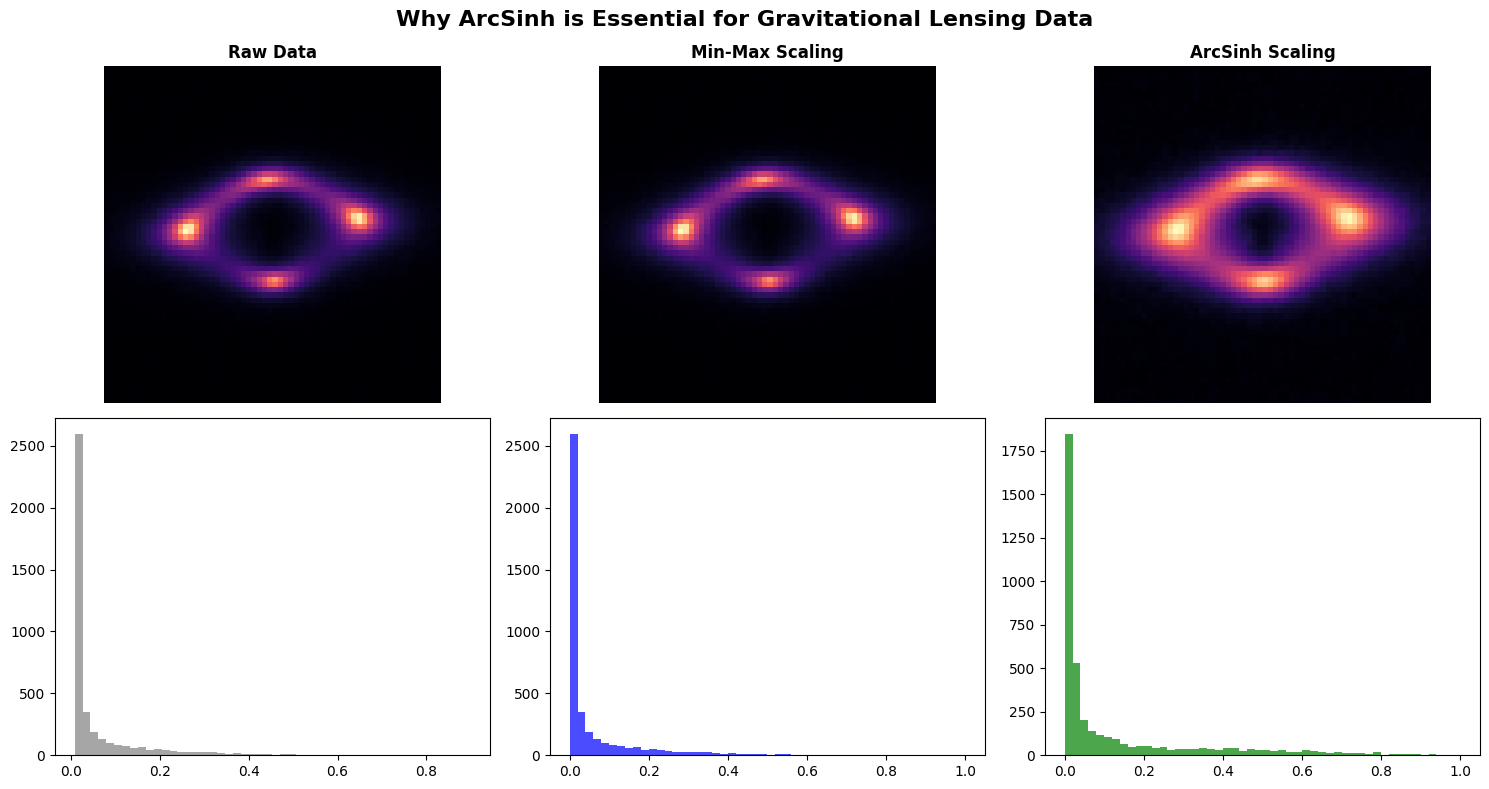

Epoch 10/60: 100%|██████████| 313/313 [01:11<00:00,  4.35it/s, MSE=0.00274]


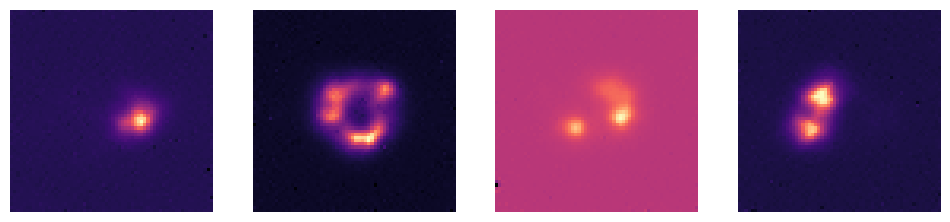

Epoch 20/60: 100%|██████████| 313/313 [01:11<00:00,  4.35it/s, MSE=0.00322]


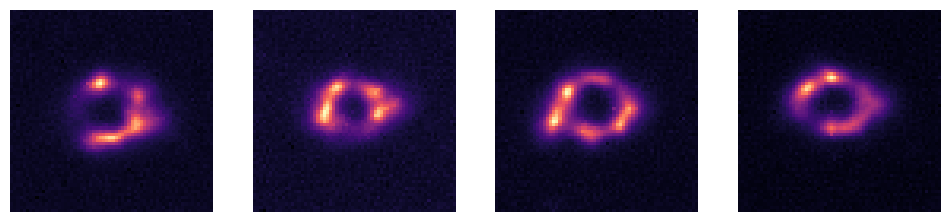

Epoch 30/60: 100%|██████████| 313/313 [01:11<00:00,  4.35it/s, MSE=0.00377]


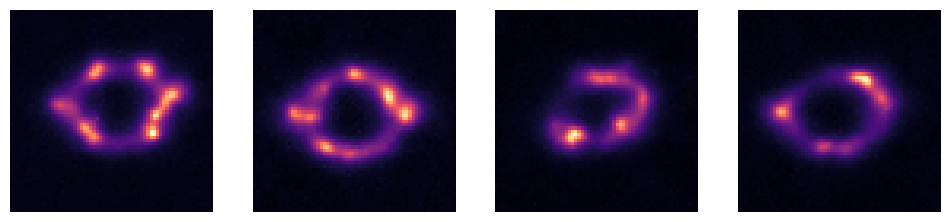

Epoch 40/60: 100%|██████████| 313/313 [01:11<00:00,  4.35it/s, MSE=0.00492]


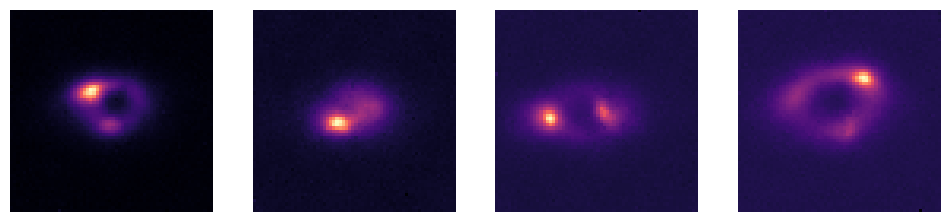

Epoch 50/60: 100%|██████████| 313/313 [01:12<00:00,  4.34it/s, MSE=0.0011]


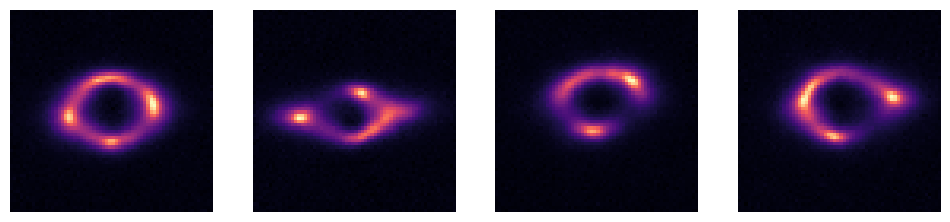

Epoch 60/60: 100%|██████████| 313/313 [01:11<00:00,  4.35it/s, MSE=0.00384]


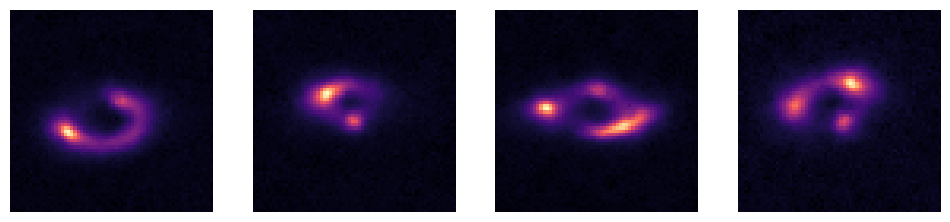

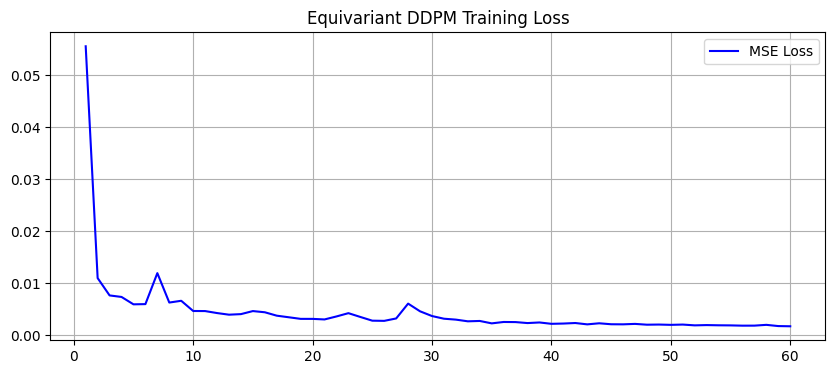

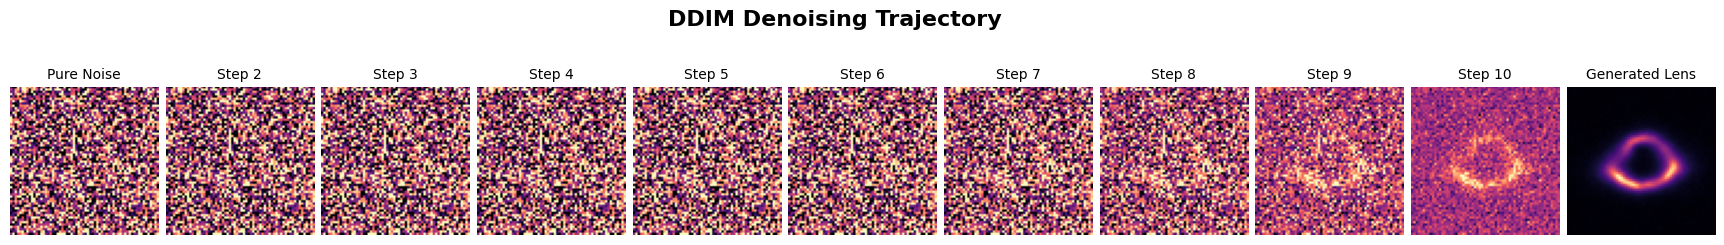

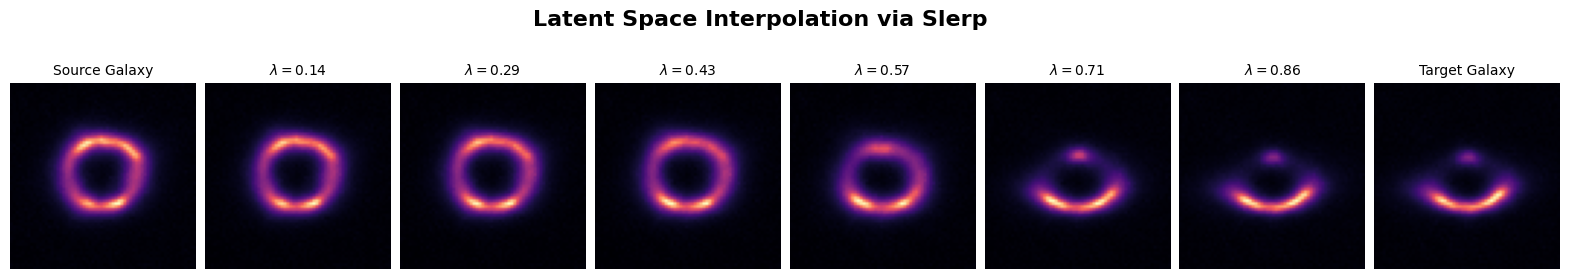

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 183MB/s]



FINAL FID SCORE: 43.9150
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 193MB/s] 


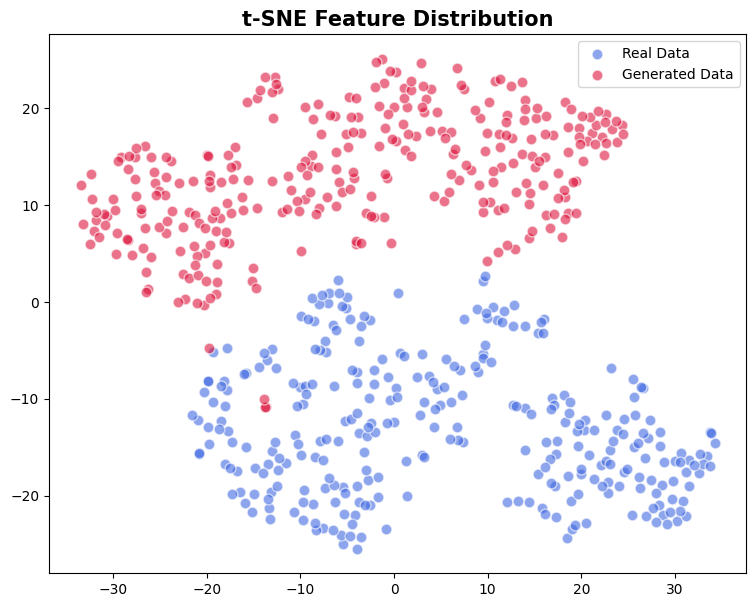

In [7]:
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    epochs = 60 
    batch_size = 32
    image_size = 64
    dataset_path = "/kaggle/input/datasets/happysaxena/ddpm-deeplense/Samples" 
    
    visualize_scaling_comparison(dataset_path, image_size)
    
    dataset = LensingNumpyDataset(dataset_path, image_size, scaling=None)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    
    # 3. Model Init (EQUIVARIANT DDPM)
    # --> THIS IS THE ONLY LOGIC CHANGE <--
    model = UNet(img_ch=1, use_equivariant=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=image_size, device=device)

    loss_history = []
    patience, min_delta, best_loss, patience_counter = 10, 1e-4, float('inf'), 0

    for epoch in range(epochs):
        epoch_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        for images in pbar:
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.q_sample(images, t)
            
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        if avg_loss < best_loss - min_delta:
            best_loss = avg_loss
            patience_counter = 0
            torch.save(model.state_dict(), "unet_equivariant_best.pt")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"\n[!] Early stopping at epoch {epoch+1}.")
            epochs = epoch + 1 
            break
        
        if (epoch + 1) % 10 == 0:
            save_samples(diffusion.ddim_sample_loop(model, n=4, ddim_timesteps=50), epoch + 1)
            
    model.load_state_dict(torch.load("unet_equivariant_best.pt"))
    model.eval() 
    
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, epochs + 1), loss_history, label='MSE Loss', color='blue')
    plt.title('Equivariant DDPM Training Loss')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    _, trajectory = diffusion.ddim_sample_loop(model, n=1, ddim_timesteps=50, return_trajectory=True)
    visualize_denoising_trajectory(trajectory)
    visualize_noise_interpolation(model, diffusion, device=device, num_steps=8)
    evaluate_model(model, diffusion, dataloader, num_samples=1000, device=device)

if __name__ == '__main__':
    train()